<a href="https://colab.research.google.com/github/Shaurya-34/Glance---Recurrent-Attention-Model/blob/main/Glance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Attention Model (RAM) Implementation
This notebook implements a Recurrent Attention Model that uses a multi-scale 'glimpse' mechanism and a reinforcement learning-based policy to classify digits within large, noisy canvases.

In [3]:
import os

!rm -f mnist-dataset.zip
!kaggle datasets download -d hojjatk/mnist-dataset
!unzip -q mnist-dataset.zip -d mnist_raw

Dataset URL: https://www.kaggle.com/datasets/hojjatk/mnist-dataset
License(s): copyright-authors
100% 22.0M/22.0M [00:00<00:00, 143MB/s] 



## 1. Data Preparation
We begin by downloading and extracting the raw MNIST dataset.

In [4]:
# Converting dataset into numpy array
import numpy as np

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        f.read(16)
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(-1, 28, 28)

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        f.read(8)
        return np.frombuffer(f.read(), dtype=np.uint8)

X_train_np = load_mnist_images('mnist_raw/train-images.idx3-ubyte')
y_train_np = load_mnist_labels('mnist_raw/train-labels.idx1-ubyte')

In [5]:
# Converting numpy array into tensors
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(1) / 255.0
y_tensor = torch.tensor(y_train_np, dtype=torch.long)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## 2. Glimpse Sensor Development
The core of the RAM is the Glimpse Sensor, which mimics human vision by extracting high-resolution patches from specific locations and multi-scale 'retina' views.

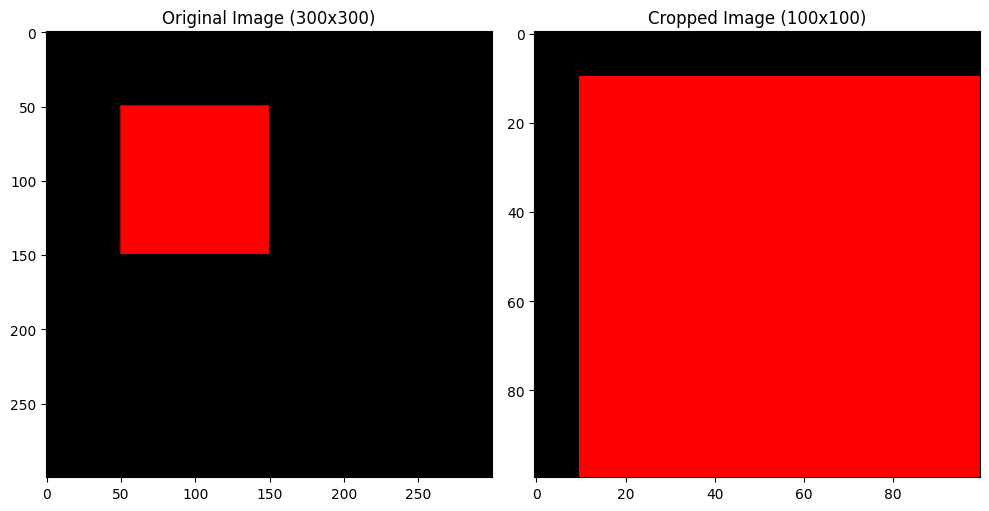

In [6]:
# Testing zoom logic
import torch
import matplotlib.pyplot as plt

image = torch.zeros(3, 300, 300)
image[0, 50:150, 50:150] = 1.0

cropped_image = image[:, 40:140, 40:140]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Original Image (300x300)")
axes[0].axis('on')

axes[1].imshow(cropped_image.permute(1, 2, 0))
axes[1].set_title("Cropped Image (100x100)")
axes[1].axis('on')

plt.tight_layout()
plt.show()

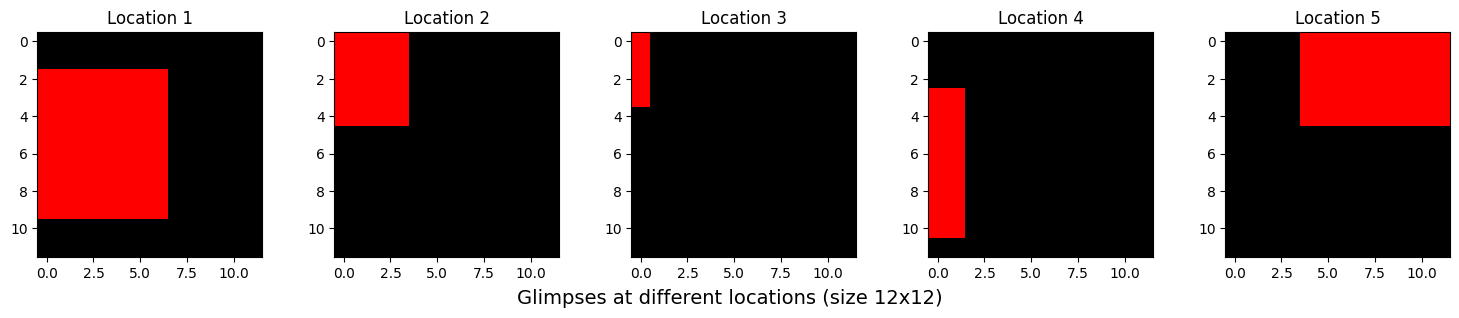

In [7]:
# Glimpse Sensor testing on Single scale
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

image = torch.zeros(3, 300, 300)
image[0, 50:150, 50:150] = 1.0
input_image = image.unsqueeze(0).repeat(5, 1, 1, 1)

max_h = input_image.size(2)
max_w = input_image.size(3)
scale = 2.0
theta_list = []

for _ in range(5):
    x = torch.randint(0, max_w, (1,)).item()
    y = torch.randint(0, max_h, (1,)).item()
    norm_x = ((x + 0.5) / max_w) * 2.0 - 1.0
    norm_y = ((y + 0.5) / max_h) * 2.0 - 1.0
    t = torch.tensor([[1.0/scale, 0.0, norm_x * (1.0 - 1.0/scale)], [0.0, 1.0/scale, norm_y * (1.0 - 1.0/scale)]], dtype=torch.float)
    theta_list.append(t)

theta = torch.stack(theta_list, dim=0)
patch_size = 12
grid = F.affine_grid(theta, size=(5, 3, patch_size, patch_size), align_corners=False)
output = F.grid_sample(input_image, grid, align_corners=False, mode='bilinear', padding_mode='zeros')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img_data = output[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img_data)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

torch.Size([9, 32, 32])


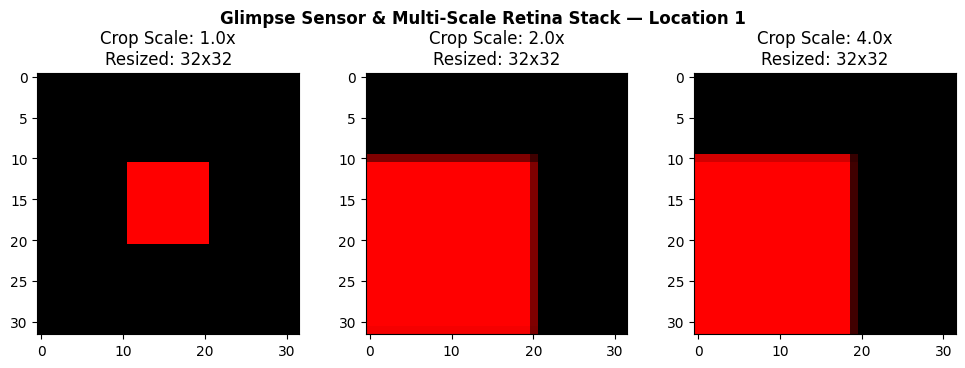

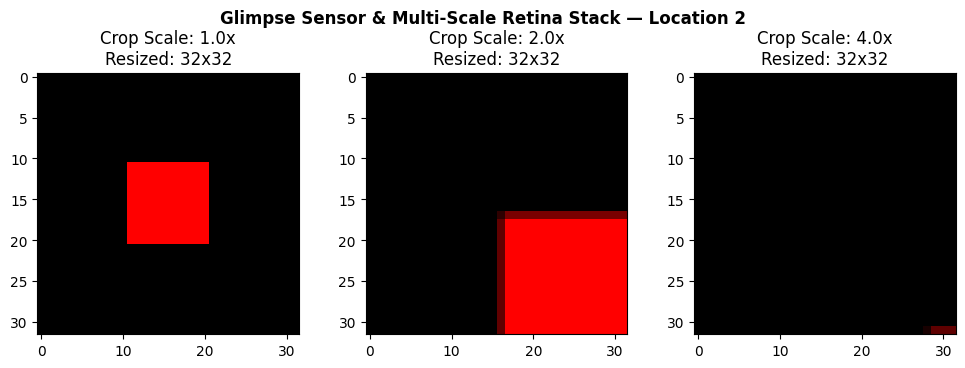

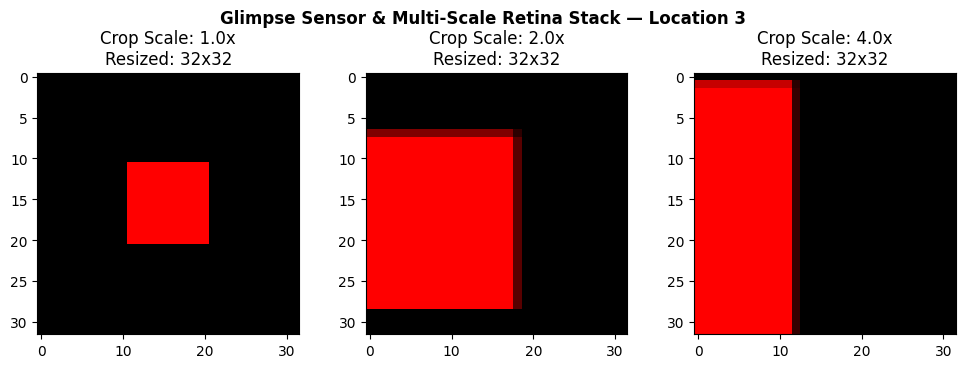

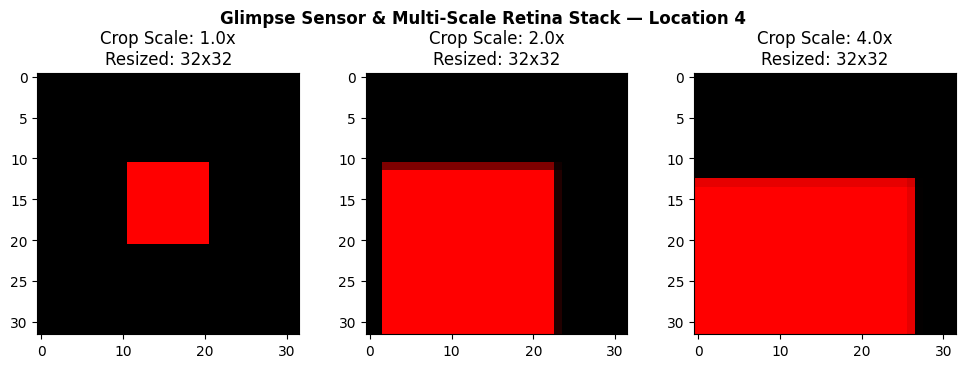

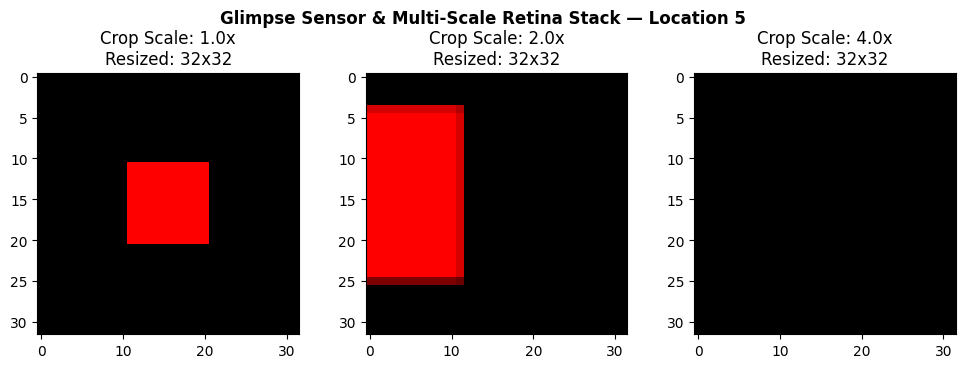

In [8]:
#Glimpse sensor with mutliscale resolution
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

image = torch.zeros(3, 300, 300)
image[0, 100:200, 100:200] = 1.0

input_image = image.unsqueeze(0).repeat(5, 1, 1, 1)
max_h, max_w = input_image.size(2), input_image.size(3)

patch_size = 32
zoom_factors = [1.0, 2.0, 4.0]

locations = []
for _ in range(5):
    x = torch.randint(0, max_w, (1,)).item()
    y = torch.randint(0, max_h, (1,)).item()
    norm_x = ((x + 0.5) / max_w) * 2.0 - 1.0
    norm_y = ((y + 0.5) / max_h) * 2.0 - 1.0
    locations.append((norm_x, norm_y))

location_glimpses = {i: [] for i in range(5)}

for zoom in zoom_factors:
    theta_list = []
    for norm_x, norm_y in locations:
        t = torch.tensor([
            [1.0 / zoom, 0.0,        norm_x * (1.0 - 1.0 / zoom)],
            [0.0,        1.0 / zoom, norm_y * (1.0 - 1.0 / zoom)],
        ], dtype=torch.float)
        theta_list.append(t)

    theta = torch.stack(theta_list, dim=0)


    native_size = int(round(patch_size * zoom))
    grid = F.affine_grid(theta, size=(5, 3, native_size, native_size), align_corners=False)
    raw_crop = F.grid_sample(input_image, grid, align_corners=False, mode='bilinear', padding_mode='zeros')


    sampled_patches = F.interpolate(raw_crop, size=(patch_size, patch_size), mode='area')

    for i in range(5):
        location_glimpses[i].append(sampled_patches[i])

glimpses = {}
for i in range(5):
    glimpses[i] = torch.cat(location_glimpses[i], dim=0)

print(glimpses[0].shape)

for loc_idx in range(5):
    fig, axes = plt.subplots(1, len(zoom_factors), figsize=(10, 3.5))

    for scale_idx, patch_tensor in enumerate(location_glimpses[loc_idx]):
        img_data = patch_tensor.permute(1, 2, 0).numpy()

        axes[scale_idx].imshow(img_data)
        axes[scale_idx].set_title(f"Crop Scale: {zoom_factors[scale_idx]}x\nResized: {patch_size}x{patch_size}")
        axes[scale_idx].axis('on')

    plt.suptitle(f"Glimpse Sensor & Multi-Scale Retina Stack — Location {loc_idx + 1}", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
# Building the Glimpse Network
import torch
import torch.nn as nn

class Glimpse_Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.model1 = nn.Sequential(nn.Linear(9216, 128), nn.ReLU())
        self.model2 = nn.Sequential(nn.Linear(2, 128), nn.ReLU())
        self.model3 = nn.Sequential(nn.Linear(128, 128), nn.ReLU())

    def forward(self, x, location):
        flattened = x.flatten(start_dim=1)
        h_g = self.model1(flattened)
        h_l = self.model2(location)
        gt = self.model3(h_g + h_l)
        return gt

torch.Size([5, 128])


## 3. Network Components
We define the Glimpse Network (to process patches), the Core RNN (to maintain state), and the Location/Action heads (to decide movement and classification).

In [10]:
#Glimpse Core

import torch
import torch.nn as nn

B = 5
glimpse_dim = 128
hidden_dim = 256
num_glimpses = 6

core = nn.LSTMCell(input_size=glimpse_dim, hidden_size=hidden_dim)


h = torch.zeros(B, hidden_dim)
c = torch.zeros(B, hidden_dim)

for t in range(num_glimpses):

    g_t = torch.randn(B, glimpse_dim)

    h, c = core(g_t, (h, c))

    print(f"Timestep {t} - Hidden state shape:", h.shape)


Timestep 0 - Hidden state shape: torch.Size([5, 256])
Timestep 1 - Hidden state shape: torch.Size([5, 256])
Timestep 2 - Hidden state shape: torch.Size([5, 256])
Timestep 3 - Hidden state shape: torch.Size([5, 256])
Timestep 4 - Hidden state shape: torch.Size([5, 256])
Timestep 5 - Hidden state shape: torch.Size([5, 256])


In [11]:
# Location Network + Action Network
import torch
import torch.nn as nn

class LocationNetwork(nn.Module):
    def __init__(self, hidden_dim):
        super(LocationNetwork, self).__init__()
        self.layer1 = nn.Linear(hidden_dim, 2)
    def forward(self, x):
        return self.layer1(x)

class ActionNetwork(nn.Module):
    def __init__(self, hidden_dim, num_classes):
        super(ActionNetwork, self).__init__()
        self.layer1 = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        return self.layer1(x)

torch.Size([5, 2])
torch.Size([5, 10])


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

# ---- Retina / Glimpse Sensor ----
def glimpse_sensor(images, locations, patch_size=32, zoom_factors=[1.0, 2.0, 4.0]):
    B = images.size(0)
    scales = []
    for zoom in zoom_factors:
        theta = torch.zeros(B, 2, 3, device=images.device)
        theta[:, 0, 0] = 1.0 / zoom
        theta[:, 1, 1] = 1.0 / zoom
        theta[:, 0, 2] = locations[:, 0] * (1.0 - 1.0 / zoom)
        theta[:, 1, 2] = locations[:, 1] * (1.0 - 1.0 / zoom)

        native_size = int(round(patch_size * zoom))
        grid = F.affine_grid(theta, size=(B, images.size(1), native_size, native_size), align_corners=False)
        raw_crop = F.grid_sample(images, grid, align_corners=False, mode='bilinear', padding_mode='zeros')
        resized = F.interpolate(raw_crop, size=(patch_size, patch_size), mode='area')
        scales.append(resized)

    return torch.cat(scales, dim=1)

# ---- Glimpse Network ----
class GlimpseNetwork(nn.Module):
    def __init__(self, retina_flat_dim, glimpse_dim=128):
        super().__init__()
        self.model1 = nn.Sequential(nn.Linear(retina_flat_dim, glimpse_dim), nn.ReLU())
        self.model2 = nn.Sequential(nn.Linear(2, glimpse_dim), nn.ReLU())
        self.model3 = nn.Sequential(nn.Linear(glimpse_dim, glimpse_dim), nn.ReLU())

    def forward(self, patch, loc):
        flat = patch.flatten(start_dim=1)
        h_g = self.model1(flat)
        h_l = self.model2(loc)
        return self.model3(h_g + h_l)

# ---- Location, Action, Baseline heads ----
class LocationNetwork(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.layer1 = nn.Linear(hidden_dim, 2)
    def forward(self, x):
        return torch.tanh(self.layer1(x))

class ActionNetwork(nn.Module):
    def __init__(self, hidden_dim, num_classes):
        super().__init__()
        self.layer1 = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        return self.layer1(x)

class BaselineNetwork(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.layer1 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        return self.layer1(x).squeeze(-1)

# ---- Full RAM model ----
class RAM(nn.Module):
    def __init__(self, patch_size=32, zoom_factors=[1.0, 2.0, 4.0], channels=1,
                 glimpse_dim=128, hidden_dim=256, num_classes=10, std=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.zoom_factors = zoom_factors
        self.std = std
        retina_flat_dim = channels * len(zoom_factors) * patch_size * patch_size

        self.glimpse_net = GlimpseNetwork(retina_flat_dim, glimpse_dim)
        self.core = nn.LSTMCell(glimpse_dim, hidden_dim)
        self.location_net = LocationNetwork(hidden_dim)
        self.action_net = ActionNetwork(hidden_dim, num_classes)
        self.baseline_net = BaselineNetwork(hidden_dim)

    def forward(self, images, labels, num_glimpses=6, training=True):
        B = images.size(0)
        device = images.device
        h = torch.zeros(B, self.core.hidden_size, device=device)
        c = torch.zeros(B, self.core.hidden_size, device=device)
        loc = torch.zeros(B, 2, device=device)

        log_probs, baselines = [], []

        for t in range(num_glimpses):
            patch = glimpse_sensor(images, loc, self.patch_size, self.zoom_factors)
            g_t = self.glimpse_net(patch, loc)
            h, c = self.core(g_t, (h, c))

            loc_mean = self.location_net(h)
            baselines.append(self.baseline_net(h))

            if training:
                dist = Normal(loc_mean, self.std)
                loc = dist.sample()
                loc = torch.clamp(loc, -1.0, 1.0)
                log_probs.append(dist.log_prob(loc).sum(dim=-1))
            else:
                loc = loc_mean
                log_probs.append(torch.zeros(B, device=device))

        logits = self.action_net(h)
        classification_loss = F.cross_entropy(logits, labels)
        preds = logits.argmax(dim=1)
        R = (preds == labels).float().detach()

        log_probs = torch.stack(log_probs, dim=1)
        baselines = torch.stack(baselines, dim=1)
        R_expanded = R.unsqueeze(1).expand_as(baselines)

        baseline_loss = F.mse_loss(baselines, R_expanded)
        advantage = (R_expanded - baselines).detach()
        reinforce_loss = -(log_probs * advantage).sum(dim=1).mean()

        return {
            "logits": logits,
            "loss": classification_loss + reinforce_loss + baseline_loss,
            "accuracy": (preds == labels).float().mean().item(),
            "cls_loss": classification_loss.item()
        }

# ---- Sanity Test ----
if __name__ == "__main__":
    model = RAM(channels=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    dummy_img = torch.rand(8, 1, 28, 28)
    dummy_lab = torch.randint(0, 10, (8,))

    for i in range(3):
        out = model(dummy_img, dummy_lab)
        optimizer.zero_grad()
        out['loss'].backward()
        optimizer.step()
        print(f"Step {i} | Loss: {out['loss']:.4f} | Acc: {out['accuracy']:.2f}")

Step 0 | Loss: 2.9577 | Acc: 0.00
Step 1 | Loss: -1.1424 | Acc: 0.38
Step 2 | Loss: -0.8595 | Acc: 0.38


## 4. Full RAM Integration & Training
In this section, we assemble the full model and train it using the REINFORCE algorithm to learn a search policy alongside a standard classification objective.

In [13]:
import torch.optim as optim
from torchvision import datasets, transforms

# 1. Load MNIST Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# 2. Initialize Model, Optimizer, and Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RAM(channels=1, patch_size=8, zoom_factors=[1.0, 2.0], hidden_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3. Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(images, labels, num_glimpses=6, training=True)
        out['loss'].backward()
        optimizer.step()

        total_loss += out['loss'].item()
        # Accuracy based on returned 'accuracy' or 'logits'
        correct += (out['logits'].argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 200 == 0:
            print(f'Epoch {epoch+1} [{batch_idx}/{len(train_loader)}] | Loss: {out["loss"].item():.4f} | Batch Acc: {out["accuracy"]:.2%}')

    print(f'\n>> Epoch {epoch+1} finished. Avg Loss: {total_loss/len(train_loader):.4f} | Training Acc: {correct/total:.2%}')

# 4. Final Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        out = model(images, labels, num_glimpses=6, training=False)
        preds = out['logits'].argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f'\nFinal Test Accuracy: {correct/total:.2%}')

Epoch 1 [0/938] | Loss: 1.0927 | Batch Acc: 9.38%
Epoch 1 [200/938] | Loss: 0.0773 | Batch Acc: 76.56%
Epoch 1 [400/938] | Loss: -1.2706 | Batch Acc: 90.62%
Epoch 1 [600/938] | Loss: 0.1020 | Batch Acc: 89.06%
Epoch 1 [800/938] | Loss: 0.7524 | Batch Acc: 82.81%

>> Epoch 1 finished. Avg Loss: 0.9579 | Training Acc: 69.08%
Epoch 2 [0/938] | Loss: 1.9626 | Batch Acc: 82.81%
Epoch 2 [200/938] | Loss: 0.1288 | Batch Acc: 90.62%
Epoch 2 [400/938] | Loss: 0.5047 | Batch Acc: 90.62%
Epoch 2 [600/938] | Loss: 0.7100 | Batch Acc: 89.06%
Epoch 2 [800/938] | Loss: -0.4238 | Batch Acc: 96.88%

>> Epoch 2 finished. Avg Loss: 0.5220 | Training Acc: 86.71%
Epoch 3 [0/938] | Loss: 0.2135 | Batch Acc: 84.38%
Epoch 3 [200/938] | Loss: 1.7350 | Batch Acc: 78.12%
Epoch 3 [400/938] | Loss: -0.5554 | Batch Acc: 96.88%
Epoch 3 [600/938] | Loss: 0.0627 | Batch Acc: 96.88%
Epoch 3 [800/938] | Loss: 1.4337 | Batch Acc: 87.50%

>> Epoch 3 finished. Avg Loss: 0.4078 | Training Acc: 89.62%
Epoch 4 [0/938] | Loss:

## 5. Experiment: Translated & Cluttered Environments
We move beyond standard MNIST to test the model's ability to 'beeline' for targets and ignore noise fragments in larger 60x60 canvases.

In [14]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Dataset

class TranslatedMNIST(Dataset):
    def __init__(self, root='./data', train=True, download=True, canvas_size=60):
        self.mnist = datasets.MNIST(root=root, train=train, download=download, transform=transforms.ToTensor())
        self.canvas_size = canvas_size

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        digit, label = self.mnist[idx]
        canvas = torch.zeros((1, self.canvas_size, self.canvas_size))

        # Randomly place 28x28 digit
        max_offset = self.canvas_size - 28
        y = np.random.randint(0, max_offset + 1)
        x = np.random.randint(0, max_offset + 1)

        canvas[:, y:y+28, x:x+28] = digit
        return canvas, label

class ClutteredTranslatedMNIST(Dataset):
    def __init__(self, root='./data', train=True, download=True, canvas_size=60, num_clutter=6):
        self.mnist = datasets.MNIST(root=root, train=train, download=download, transform=transforms.ToTensor())
        self.canvas_size = canvas_size
        self.num_clutter = num_clutter

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        digit, label = self.mnist[idx]
        canvas = torch.zeros((1, self.canvas_size, self.canvas_size))

        # Place main digit
        max_offset = self.canvas_size - 28
        y = np.random.randint(0, max_offset + 1)
        x = np.random.randint(0, max_offset + 1)
        canvas[:, y:y+28, x:x+28] = digit

        # Add clutter (8x8 crops from random images)
        for _ in range(np.random.randint(4, 9)):
            rand_idx = np.random.randint(0, len(self.mnist))
            random_digit, _ = self.mnist[rand_idx]

            # Take 8x8 crop
            cy = np.random.randint(0, 28 - 8)
            cx = np.random.randint(0, 28 - 8)
            clutter_patch = random_digit[:, cy:cy+8, cx:cx+8]

            # Place on canvas avoiding center of main digit if possible
            py = np.random.randint(0, self.canvas_size - 8)
            px = np.random.randint(0, self.canvas_size - 8)
            canvas[:, py:py+8, px:px+8] = torch.max(canvas[:, py:py+8, px:px+8], clutter_patch)

        return canvas, label

### Run Experiment: Translated MNIST
Update the `train_loader` and `test_loader` to use `TranslatedMNIST` and re-run your training loop cell.

Retraining with increased std (0.25) and 8 glimpses...
Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.


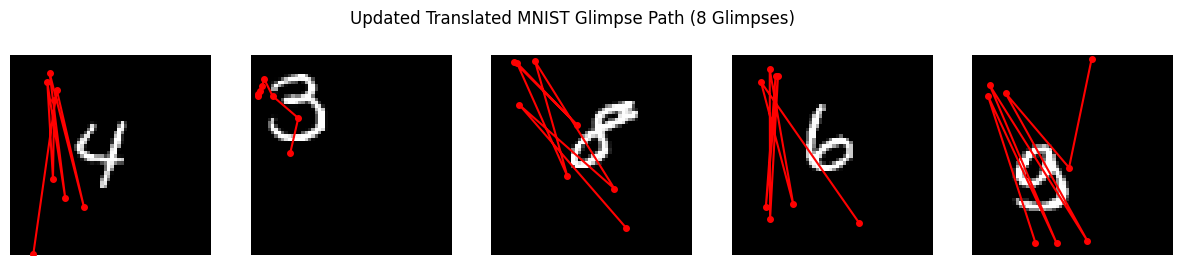

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt

def glimpse_sensor(images, locations, patch_size=8, zoom_factors=[1.0, 2.0]):
    B = images.size(0)
    scales = []
    for zoom in zoom_factors:
        theta = torch.zeros(B, 2, 3, device=images.device)
        theta[:, 0, 0] = 1.0 / zoom
        theta[:, 1, 1] = 1.0 / zoom
        theta[:, 0, 2] = locations[:, 0] * (1.0 - 1.0 / zoom)
        theta[:, 1, 2] = locations[:, 1] * (1.0 - 1.0 / zoom)
        native_size = int(round(patch_size * zoom))
        grid = F.affine_grid(theta, size=(B, images.size(1), native_size, native_size), align_corners=False)
        raw_crop = F.grid_sample(images, grid, align_corners=False, mode='bilinear', padding_mode='zeros')
        resized = F.interpolate(raw_crop, size=(patch_size, patch_size), mode='area')
        scales.append(resized)
    return torch.cat(scales, dim=1)

class RAM(nn.Module):
    def __init__(self, patch_size=8, zoom_factors=[1.0, 2.0], channels=1, glimpse_dim=128, hidden_dim=256, num_classes=10, std=0.25):
        super().__init__()
        self.patch_size, self.zoom_factors, self.std = patch_size, zoom_factors, std
        retina_flat_dim = channels * len(zoom_factors) * patch_size * patch_size
        self.glimpse_net = GlimpseNetwork(retina_flat_dim, glimpse_dim)
        self.core = nn.LSTMCell(glimpse_dim, hidden_dim)
        self.location_net = nn.Sequential(nn.Linear(hidden_dim, 2), nn.Tanh())
        self.action_net = nn.Linear(hidden_dim, num_classes)
        self.baseline_net = nn.Linear(hidden_dim, 1)

    def forward(self, images, labels, num_glimpses=8, training=True):
        B, device = images.size(0), images.device
        h = torch.zeros(B, self.core.hidden_size, device=device)
        c = torch.zeros(B, self.core.hidden_size, device=device)
        # Initialize location randomly in [-1, 1]
        loc = torch.empty(B, 2, device=device).uniform_(-1, 1)
        log_probs, baselines, locations = [], [], []

        for t in range(num_glimpses):
            locations.append(loc)
            patch = glimpse_sensor(images, loc, self.patch_size, self.zoom_factors)
            g_t = self.glimpse_net(patch, loc)
            h, c = self.core(g_t, (h, c))
            loc_mean = self.location_net(h)
            baselines.append(self.baseline_net(h).squeeze(-1))
            if training:
                dist = Normal(loc_mean, self.std)
                loc = torch.clamp(dist.sample(), -1.0, 1.0)
                log_probs.append(dist.log_prob(loc).sum(dim=-1))
            else:
                loc = loc_mean
                log_probs.append(torch.zeros(B, device=device))

        logits = self.action_net(h)
        preds = logits.argmax(dim=1)
        R = (preds == labels).float().detach()
        log_probs, baselines = torch.stack(log_probs, dim=1), torch.stack(baselines, dim=1)
        R_exp = R.unsqueeze(1).expand_as(baselines)
        loss = F.cross_entropy(logits, labels) + -(log_probs * (R_exp - baselines).detach()).sum(dim=1).mean() + F.mse_loss(baselines, R_exp)
        return {"logits": logits, "loss": loss, "accuracy": R.mean().item(), "locations": torch.stack(locations, dim=1)}

# Training logic
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RAM(std=0.25).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
train_loader = DataLoader(TranslatedMNIST(train=True), batch_size=64, shuffle=True)

print("Retraining with increased std (0.25) and 8 glimpses...")
for epoch in range(5):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs, lbls, num_glimpses=8, training=True)
        out['loss'].backward()
        optimizer.step()
    print(f"Epoch {epoch+1} finished.")

# Visualize updated glimpses
visualize_glimpses(TranslatedMNIST(train=False), model, "Updated Translated MNIST Glimpse Path (8 Glimpses)")

In [16]:
def evaluate_model(dataset, model, num_glimpses=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs, lbls, num_glimpses=num_glimpses, training=False)
            preds = out['logits'].argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

acc_trans_new = evaluate_model(TranslatedMNIST(train=False), model)
acc_clut_new = evaluate_model(ClutteredTranslatedMNIST(train=False), model)

print(f"Current Test Accuracy (Translated): {acc_trans_new:.2%}")
print(f"Current Test Accuracy (Cluttered): {acc_clut_new:.2%}")

Current Test Accuracy (Translated): 57.44%
Current Test Accuracy (Cluttered): 29.63%


Continuing training for 20 more epochs to stabilize search policy...
Finished Epoch 5/20 | Avg Loss: 0.7175
Finished Epoch 10/20 | Avg Loss: 0.5191
Finished Epoch 15/20 | Avg Loss: 0.4003
Finished Epoch 20/20 | Avg Loss: 0.3074

Final Test Accuracy after extended training: 92.49%


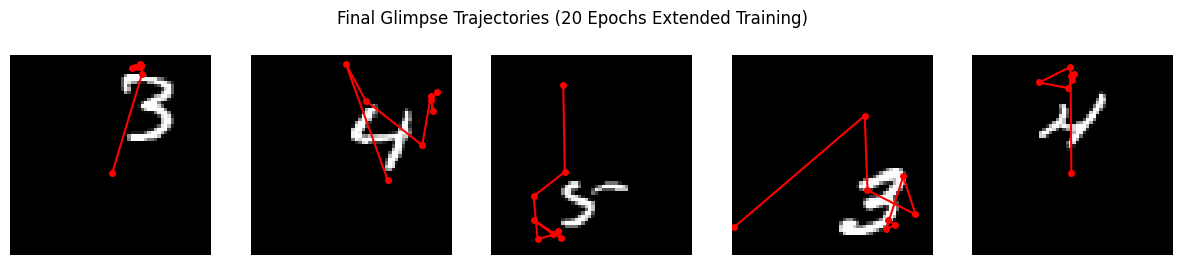

In [17]:
print("Continuing training for 20 more epochs to stabilize search policy...")
extra_epochs = 20
for epoch in range(extra_epochs):
    model.train()
    epoch_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs, lbls, num_glimpses=8, training=True)
        out['loss'].backward()
        optimizer.step()
        epoch_loss += out['loss'].item()

    if (epoch + 1) % 5 == 0:
        print(f"Finished Epoch {epoch + 1}/{extra_epochs} | Avg Loss: {epoch_loss/len(train_loader):.4f}")

# Final Evaluation and Visualization
final_acc = evaluate_model(TranslatedMNIST(train=False), model)
print(f"\nFinal Test Accuracy after extended training: {final_acc:.2%}")
visualize_glimpses(TranslatedMNIST(train=False), model, "Final Glimpse Trajectories (20 Epochs Extended Training)")

### Experiment: Cluttered Translated MNIST
We will now train the model specifically on the cluttered version of the dataset. The goal is to observe if the model learns to ignore noise and focus on the digit.

### Visualize Clutter Trajectories
Let's see if the glimpse path ignores the 8x8 clutter patches.

Active Device: cuda
Continuing training on Cluttered MNIST for 25 additional epochs...
Extended Epoch 5/25 | Test Acc: 22.36%
Extended Epoch 10/25 | Test Acc: 33.51%
Extended Epoch 15/25 | Test Acc: 50.88%
Extended Epoch 20/25 | Test Acc: 63.60%
Extended Epoch 25/25 | Test Acc: 66.90%

Final Test Accuracy: 67.39%


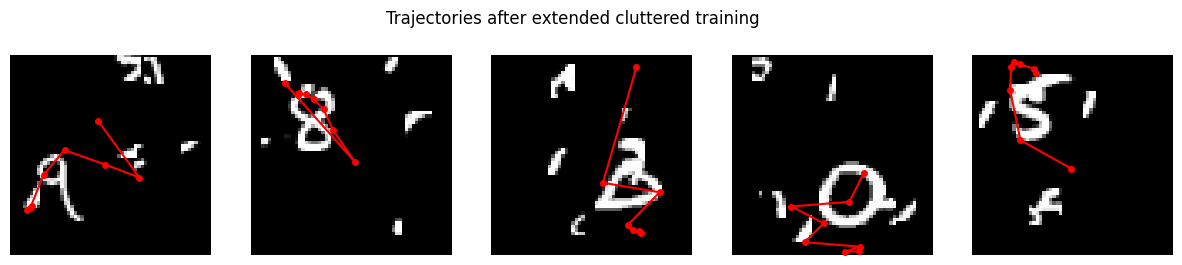

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.distributions import Normal
import matplotlib.pyplot as plt
import numpy as np

# --- Device Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device}")

# --- Helper: Glimpse Sensor ---
def glimpse_sensor(images, locations, patch_size=8, zoom_factors=[1.0, 2.0]):
    B = images.size(0)
    scales = []
    for zoom in zoom_factors:
        theta = torch.zeros(B, 2, 3, device=images.device)
        theta[:, 0, 0] = 1.0 / zoom
        theta[:, 1, 1] = 1.0 / zoom
        theta[:, 0, 2] = locations[:, 0] * (1.0 - 1.0 / zoom)
        theta[:, 1, 2] = locations[:, 1] * (1.0 - 1.0 / zoom)
        native_size = int(round(patch_size * zoom))
        grid = F.affine_grid(theta, size=(B, images.size(1), native_size, native_size), align_corners=False)
        raw_crop = F.grid_sample(images, grid, align_corners=False, mode='bilinear', padding_mode='zeros')
        resized = F.interpolate(raw_crop, size=(patch_size, patch_size), mode='area')
        scales.append(resized)
    return torch.cat(scales, dim=1)

# --- Networks & RAM Definitions ---
class GlimpseNetwork(nn.Module):
    def __init__(self, retina_flat_dim, glimpse_dim=128):
        super().__init__()
        self.model1 = nn.Sequential(nn.Linear(retina_flat_dim, glimpse_dim), nn.ReLU())
        self.model2 = nn.Sequential(nn.Linear(2, glimpse_dim), nn.ReLU())
        self.model3 = nn.Sequential(nn.Linear(glimpse_dim, glimpse_dim), nn.ReLU())
    def forward(self, patch, loc):
        return self.model3(self.model1(patch.flatten(1)) + self.model2(loc))

class RAM(nn.Module):
    def __init__(self, patch_size=8, zoom_factors=[1.0, 2.0], channels=1, glimpse_dim=128, hidden_dim=256, num_classes=10, std=0.25):
        super().__init__()
        self.patch_size, self.zoom_factors, self.std = patch_size, zoom_factors, std
        retina_flat_dim = channels * len(zoom_factors) * patch_size * patch_size
        self.glimpse_net = GlimpseNetwork(retina_flat_dim, glimpse_dim)
        self.core = nn.LSTMCell(glimpse_dim, hidden_dim)
        self.location_net = nn.Sequential(nn.Linear(hidden_dim, 2), nn.Tanh())
        self.action_net = nn.Linear(hidden_dim, num_classes)
        self.baseline_net = nn.Linear(hidden_dim, 1)

    def forward(self, images, labels, num_glimpses=8, training=True):
        B, device = images.size(0), images.device
        h = torch.zeros(B, self.core.hidden_size, device=device)
        c = torch.zeros(B, self.core.hidden_size, device=device)
        loc = torch.empty(B, 2, device=device).uniform_(-1, 1)
        log_probs, baselines, locations = [], [], []
        for t in range(num_glimpses):
            locations.append(loc)
            patch = glimpse_sensor(images, loc, self.patch_size, self.zoom_factors)
            g_t = self.glimpse_net(patch, loc)
            h, c = self.core(g_t, (h, c))
            loc_mean = self.location_net(h)
            baselines.append(self.baseline_net(h).squeeze(-1))
            if training:
                dist = Normal(loc_mean, self.std)
                loc = torch.clamp(dist.sample(), -1.0, 1.0)
                log_probs.append(dist.log_prob(loc).sum(dim=-1))
            else:
                loc = loc_mean
                log_probs.append(torch.zeros(B, device=device))
        logits = self.action_net(h)
        preds = logits.argmax(dim=1)
        R = (preds == labels).float().detach()
        log_probs, baselines = torch.stack(log_probs, 1), torch.stack(baselines, 1)
        R_exp = R.unsqueeze(1).expand_as(baselines)
        loss = F.cross_entropy(logits, labels) + -(log_probs * (R_exp - baselines).detach()).sum(1).mean() + F.mse_loss(baselines, R_exp)
        return {"logits": logits, "loss": loss, "accuracy": R.mean().item(), "locations": torch.stack(locations, 1)}

# --- Dataset and Helpers ---
class ClutteredTranslatedMNIST(Dataset):
    def __init__(self, root='./data', train=True, download=True, canvas_size=60, num_clutter=6):
        self.mnist = datasets.MNIST(root=root, train=train, download=download, transform=transforms.ToTensor())
        self.canvas_size, self.num_clutter = canvas_size, num_clutter
    def __len__(self):
        return len(self.mnist)
    def __getitem__(self, idx):
        digit, label = self.mnist[idx]
        canvas = torch.zeros((1, self.canvas_size, self.canvas_size))
        y, x = np.random.randint(0, self.canvas_size - 28 + 1, size=2)
        canvas[:, y:y+28, x:x+28] = digit
        for _ in range(self.num_clutter):
            patch, _ = self.mnist[np.random.randint(len(self.mnist))]
            cy, cx = np.random.randint(0, 20, size=2)
            py, px = np.random.randint(0, self.canvas_size - 8, size=2)
            canvas[:, py:py+8, px:px+8] = torch.max(canvas[:, py:py+8, px:px+8], patch[:, cy:cy+8, cx:cx+8])
        return canvas, label

def evaluate_model(dataset, model, batch_size=256):
    model.eval()
    device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs, lbls, training=False)
            preds = out['logits'].argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

def visualize_glimpses(dataset, model, title="Glimpse Trajectories", num_samples=5):
    model.eval()
    device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=num_samples, shuffle=True)
    imgs, lbls = next(iter(loader))
    with torch.no_grad():
        out = model(imgs.to(device), lbls.to(device), training=False)
        locs = out['locations'].cpu().numpy()
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        axes[i].imshow(imgs[i, 0], cmap='gray')
        c = imgs.shape[-1]
        axes[i].plot((locs[i, :, 0] + 1) / 2 * c, (locs[i, :, 1] + 1) / 2 * c, '-o', color='red', markersize=4)
        axes[i].axis('off')
    plt.suptitle(title); plt.show()

# --- 1. Load Data with Optimized Settings ---
train_loader_clut = DataLoader(ClutteredTranslatedMNIST(train=True), batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_clut = ClutteredTranslatedMNIST(train=False)

# Re-using existing model/optimizer if possible
if 'model_clut' not in globals():
    model_clut = RAM(std=0.25).to(device)
    optimizer_clut = optim.Adam(model_clut.parameters(), lr=1e-3)

# --- 2. Extended Training ---
print("Continuing training on Cluttered MNIST for 25 additional epochs...")
extra_epochs = 25
for epoch in range(extra_epochs):
    model_clut.train()
    for imgs, lbls in train_loader_clut:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_clut.zero_grad()
        model_clut(imgs, lbls, training=True)['loss'].backward()
        optimizer_clut.step()

    if (epoch + 1) % 5 == 0:
        acc = evaluate_model(test_clut, model_clut)
        print(f"Extended Epoch {epoch + 1}/{extra_epochs} | Test Acc: {acc:.2%}")

# --- 3. Output Results ---
final_acc = evaluate_model(test_clut, model_clut)
print(f"\nFinal Test Accuracy: {final_acc:.2%}")
visualize_glimpses(test_clut, model_clut, 'Trajectories after extended cluttered training')

## 6. Policy Refinement & Trajectory Visualization
Finally, we perform extended training cycles to stabilize the search policy and visualize the paths taken by the model to verify its behavior in cluttered environments.

Resuming training on Cluttered MNIST for another 25 epochs...
Extended Epoch 5/25 | Avg Loss: 0.9947 | Test Acc: 72.51%
Extended Epoch 10/25 | Avg Loss: 0.8903 | Test Acc: 78.38%
Extended Epoch 15/25 | Avg Loss: 0.8082 | Test Acc: 77.94%
Extended Epoch 20/25 | Avg Loss: 0.7398 | Test Acc: 80.39%
Extended Epoch 25/25 | Avg Loss: 0.7055 | Test Acc: 80.71%

Updated Final Test Accuracy: 81.15%


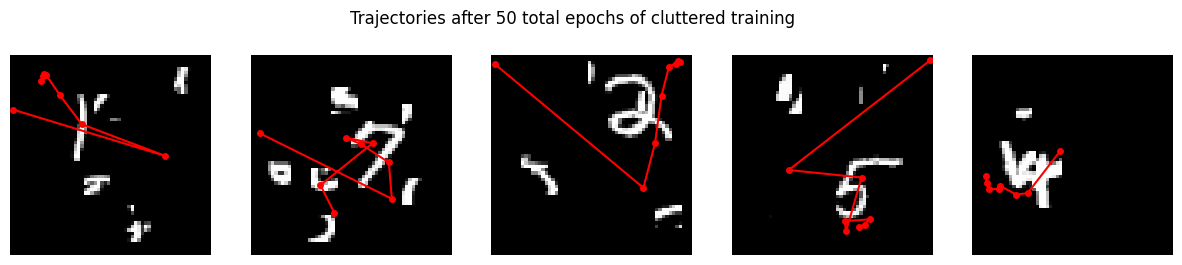

In [19]:
print("Resuming training on Cluttered MNIST for another 25 epochs...")
extra_epochs = 25

for epoch in range(extra_epochs):
    model_clut.train()
    epoch_loss = 0
    for imgs, lbls in train_loader_clut:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_clut.zero_grad()
        out = model_clut(imgs, lbls, training=True)
        out['loss'].backward()
        optimizer_clut.step()
        epoch_loss += out['loss'].item()

    if (epoch + 1) % 5 == 0:
        acc = evaluate_model(test_clut, model_clut)
        print(f"Extended Epoch {epoch + 1}/{extra_epochs} | Avg Loss: {epoch_loss/len(train_loader_clut):.4f} | Test Acc: {acc:.2%}")

final_acc = evaluate_model(test_clut, model_clut)
print(f"\nUpdated Final Test Accuracy: {final_acc:.2%}")
visualize_glimpses(test_clut, model_clut, 'Trajectories after 50 total epochs of cluttered training')


Resuming training on Cluttered MNIST for epochs 51-75...
Extended Epoch 55/75 | Avg Loss: 0.6686 | Test Acc: 82.02%
Extended Epoch 60/75 | Avg Loss: 0.6395 | Test Acc: 82.37%
Extended Epoch 65/75 | Avg Loss: 0.6341 | Test Acc: 83.40%
Extended Epoch 70/75 | Avg Loss: 0.6124 | Test Acc: 83.10%
Extended Epoch 75/75 | Avg Loss: 0.5873 | Test Acc: 84.17%

Final Test Accuracy (after 75 epochs): 84.09%


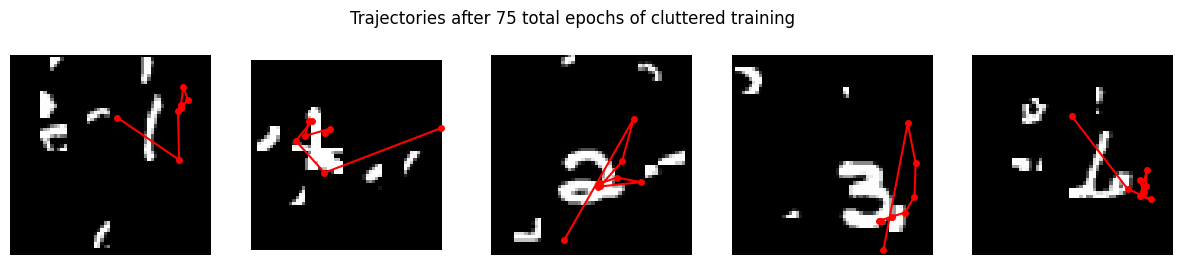

In [20]:
print("Resuming training on Cluttered MNIST for epochs 51-75...")
extra_epochs = 25

for epoch in range(extra_epochs):
    model_clut.train()
    epoch_loss = 0
    for imgs, lbls in train_loader_clut:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_clut.zero_grad()
        out = model_clut(imgs, lbls, training=True)
        out['loss'].backward()
        optimizer_clut.step()
        epoch_loss += out['loss'].item()

    if (epoch + 1) % 5 == 0:
        acc = evaluate_model(test_clut, model_clut)
        print(f"Extended Epoch {epoch + 51}/75 | Avg Loss: {epoch_loss/len(train_loader_clut):.4f} | Test Acc: {acc:.2%}")

final_acc = evaluate_model(test_clut, model_clut)
print(f"\nFinal Test Accuracy (after 75 epochs): {final_acc:.2%}")
visualize_glimpses(test_clut, model_clut, 'Trajectories after 75 total epochs of cluttered training')
